# HIFtool MoG-DCN — HARVARD Dataset Evaluation

In [1]:
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install imgvision einops scipy --no-deps -q
!git clone https://github.com/Nikesh0907/HIFtool.git /kaggle/working/HIFtool 2>/dev/null || true

In [2]:
import os, sys, glob, argparse, time
import numpy as np, torch, torch.nn as nn
import scipy.io as sio, torch.utils.data as data
import matplotlib.pyplot as plt, imgvision as iv

HIFTOOL_DIR = '/kaggle/working/HIFtool'
sys.path.insert(0, HIFTOOL_DIR)

device = 'cpu'
if torch.cuda.is_available():
    try:
        x = torch.randn(1,1,4,4).cuda()
        torch.nn.functional.interpolate(x, scale_factor=2, mode='bilinear')
        device = 'cuda'
        print(f'GPU OK: {torch.cuda.get_device_name()}')
    except: print('GPU broken, using CPU')
print(f'Device: {device}  |  PyTorch: {torch.__version__}')

DATA_ROOT = '/kaggle/input/harvard-hsi-2/Data'
CKPT_PATH = sorted(glob.glob('/kaggle/input/model-mogdcn/**/*.pth', recursive=True))[0]

all_mat = sorted(glob.glob(os.path.join(DATA_ROOT, '**', '*.mat'), recursive=True))
test_mats = [f for f in all_mat if '/Test/HSI/' in f]
print(f'Test HSI files: {len(test_mats)}')
print(f'Checkpoint: {CKPT_PATH}')

GPU OK: Tesla T4
Device: cuda  |  PyTorch: 2.4.1+cu121
Test HSI files: 20
Checkpoint: /kaggle/input/model-mogdcn/pytorch/default/1/2000.pth


In [3]:
def load_hsi(filepath):
    try:
        d = sio.loadmat(filepath)
    except NotImplementedError:
        import h5py
        with h5py.File(filepath, 'r') as f:
            d = {k: np.array(f[k]) for k in f.keys()}
    if 'hsi' in d: gt = d['hsi'].astype(np.float64)
    elif 'HSI' in d: gt = d['HSI'].astype(np.float64)
    else:
        arrays = {k:v for k,v in d.items() if not k.startswith('__') and hasattr(v,'shape') and v.ndim>=2}
        gt = max(arrays.values(), key=lambda v: v.size).astype(np.float64)
    if gt.ndim == 3 and gt.shape[0] <= 31 and gt.shape[2] > 31:
        gt = gt.transpose(1, 2, 0)
    if gt.max() > 1.0: gt = gt / gt.max()
    return gt

sample = load_hsi(test_mats[0])
print(f'Verified: {os.path.basename(test_mats[0])} -> {sample.shape} ✓')

Verified: imga5.mat -> (1040, 1392, 31) ✓


## Build MoG-DCN model

In [4]:
from Networks.MoGDCN.net import VSR_CAS

opt = argparse.Namespace(
    sf=32,
    patch_size=512,       # full image size
    msi_channel=3,
    hsi_channel=31,
)

model = VSR_CAS(opt).to(device)
print(f'MoG-DCN params: {sum(p.numel() for p in model.parameters()):,}')

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
sd = ckpt.get('net', ckpt) if isinstance(ckpt, dict) else ckpt
sd = {k.replace('module.', ''): v for k, v in sd.items()}
m, u = model.load_state_dict(sd, strict=False)
print(f'Loaded | missing:{len(m)} unexpected:{len(u)}')
if m: print(f'  Missing: {m[:5]}')
if u: print(f'  Unexpected: {u[:5]}')
model.eval()
print('MoG-DCN ready ✓')

MoG-DCN params: 6,745,956
Loaded | missing:0 unexpected:0
MoG-DCN ready ✓


## Prepare data

In [5]:
def getGk(ksize, sigma):
    x = torch.arange(-(ksize-1)//2, (ksize-1)//2+1)
    k = torch.exp(-0.5*(x/sigma)**2); k /= k.sum()
    return k.view(-1, 1).float()

class SpaDown(nn.Module):
    def __init__(self, sf):
        super().__init__()
        k = getGk(sf, sf/1.5); k = k @ k.T
        self.down = nn.Conv2d(1, 1, sf, sf, bias=False)
        self.down.weight.data[0, 0] = k
        self.down.requires_grad_(False)
    def forward(self, x):
        return self.down(x.transpose(1, 0)).transpose(1, 0)

SRF = np.load(os.path.join(HIFTOOL_DIR, 'Dataloader_tool', 'srflib', 'NikonD700.npy'))
print(f'SRF: {SRF.shape}')

class HarvardDataset(data.Dataset):
    def __init__(self, mat_paths, sf, srf):
        self.HR, self.LR, self.MSI, self.names = [], [], [], []
        sp = SpaDown(sf)
        for fp in mat_paths:
            gt = load_hsi(fp)
            gt31 = gt[:, :, :srf.shape[0]]
            h, w = gt31.shape[:2]
            gt31 = gt31[:h - (h % sf), :w - (w % sf), :]
            lr = sp(torch.tensor(gt31.T).unsqueeze(0).float())[0].permute(2, 1, 0).numpy()
            msi = gt31 @ srf
            self.HR.append(gt31); self.LR.append(lr); self.MSI.append(msi)
            self.names.append(os.path.splitext(os.path.basename(fp))[0])
            print(f'  {self.names[-1]}: {gt31.shape}')
    def __getitem__(self, i):
        return (torch.FloatTensor(self.HR[i].transpose(2,0,1)),
                torch.FloatTensor(self.LR[i].transpose(2,0,1)),
                torch.FloatTensor(self.MSI[i].transpose(2,0,1)))
    def __len__(self): return len(self.HR)

print(f'Building dataset from {len(test_mats)} HSI files...')
ds = HarvardDataset(test_mats, opt.sf, SRF)
loader = data.DataLoader(ds, batch_size=1, shuffle=False)
print(f'Dataset: {len(ds)} images ✓')

SRF: (31, 3)
Building dataset from 20 HSI files...
  imga5: (1024, 1376, 31)
  imga7: (1024, 1376, 31)
  imgb5: (1024, 1376, 31)
  imgb6: (1024, 1376, 31)
  imgb7: (1024, 1376, 31)
  imgc1: (1024, 1376, 31)
  imgc5: (1024, 1376, 31)
  imgc8: (1024, 1376, 31)
  imgd2: (1024, 1376, 31)
  imgd3: (1024, 1376, 31)
  imgd9: (1024, 1376, 31)
  imge0: (1024, 1376, 31)
  imge1: (1024, 1376, 31)
  imge2: (1024, 1376, 31)
  imge4: (1024, 1376, 31)
  imge6: (1024, 1376, 31)
  imgf1: (1024, 1376, 31)
  imgf4: (1024, 1376, 31)
  imgh1: (1024, 1376, 31)
  imgh3: (1024, 1376, 31)
Dataset: 20 images ✓


## Run MoG-DCN evaluation

In [6]:
out_dir = '/kaggle/working/results_mogdcn'
os.makedirs(out_dir, exist_ok=True)
results, times = [], []

model.eval()
with torch.no_grad():
    for it, (GT_t, LR_t, MSI_t) in enumerate(loader, 1):
        # MoG-DCN forward: model(LR, RGB)
        LR_t = LR_t.to(device)
        MSI_t = MSI_t.to(device)

        t1 = time.time()
        # Chunked forward pass to avoid OOM
        h, w = LR_t.shape[2:]
        h_sp, w_sp = h // 2, w // 2
        H_sp, W_sp = h_sp * opt.sf, w_sp * opt.sf
        
        out_tensor = torch.zeros((1, 31, h*opt.sf, w*opt.sf), device=device)
        out_tensor[:, :, :H_sp, :W_sp] = model(LR_t[:, :, :h_sp, :w_sp], MSI_t[:, :, :H_sp, :W_sp])[0]
        out_tensor[:, :, :H_sp, W_sp:] = model(LR_t[:, :, :h_sp, w_sp:], MSI_t[:, :, :H_sp, W_sp:])[0]
        out_tensor[:, :, H_sp:, :W_sp] = model(LR_t[:, :, h_sp:, :w_sp], MSI_t[:, :, H_sp:, :W_sp])[0]
        out_tensor[:, :, H_sp:, W_sp:] = model(LR_t[:, :, h_sp:, w_sp:], MSI_t[:, :, H_sp:, W_sp:])[0]
        out = out_tensor
        t2 = time.time()
        times.append(t2 - t1)

        pred = out[0].cpu().permute(1, 2, 0).numpy()
        gt = GT_t[0].permute(1, 2, 0).numpy()
        name = ds.names[it - 1]

        print(f'\n--- {it}/{len(ds)} [{name}] ({t2-t1:.2f}s) ---')
        iv.spectra_metric(pred, gt).Evaluation()

        np.save(f'{out_dir}/{name}_recon.npy', pred)
        results.append({'name': name, 'pred': pred, 'gt': gt})

print(f'\nDone | {len(results)} images | avg {np.mean(times):.3f}s')


--- 1/20 [imga5] (6.78s) ---
0	60.58321256297272	12.349397659301758	11.381423950195312	0.9926836490631104	0.0012502832105383277	0.9011117815971375

--- 2/20 [imga7] (6.79s) ---
0	56.30338893613299	9.755741119384766	3.6723368167877197	0.9867287874221802	0.0019594780169427395	0.8707072138786316

--- 3/20 [imgb5] (6.96s) ---
0	58.70027544871003	12.675586700439453	10.131902694702148	0.9928065538406372	0.0014683699700981379	0.8817516565322876

--- 4/20 [imgb6] (7.28s) ---
0	57.33347735012303	9.627830505371094	9.311378479003906	0.9898248910903931	0.0016893809661269188	0.9387386441230774

--- 5/20 [imgb7] (7.45s) ---
0	53.42210402278603	11.76639175415039	12.356603622436523	0.9825636148452759	0.0024698663037270308	0.9312448501586914

--- 6/20 [imgc1] (7.54s) ---
0	60.161068683322185	17.524993896484375	9.031493186950684	0.9929320216178894	0.001243031700141728	0.7729864120483398

--- 7/20 [imgc5] (7.39s) ---
0	57.156214248696315	14.116991996765137	7.310436725616455	0.9875780940055847	0.00183854

## Results summary

In [10]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

print('=' * 90)
print(f'{"MoG-DCN Results Summary":^90}')
print('=' * 90)
print(f'{"Image":<25} {"PSNR (dB)":>10} {"SSIM":>10} {"SAM":>10} {"RMSE":>10} {"ERGAS":>10}')
print('-' * 90)

all_psnr, all_ssim, all_sam, all_rmse, all_ergas = [], [], [], [], []
for r in results:
    gt, pred = r['gt'], r['pred']
    p = psnr(gt, pred, data_range=gt.max())
    s_vals = [ssim(gt[:,:,b], pred[:,:,b], data_range=1.0) for b in range(gt.shape[-1])]
    s = np.mean(s_vals)
    gt_f, pred_f = gt.reshape(-1, gt.shape[-1]), pred.reshape(-1, pred.shape[-1])
    cos_a = np.clip(np.sum(gt_f*pred_f,1)/(np.linalg.norm(gt_f,axis=1)*np.linalg.norm(pred_f,axis=1)+1e-10),-1,1)
    sam_val = np.mean(np.arccos(cos_a))*180/np.pi
    rmse_val = np.sqrt(np.mean((gt-pred)**2))
    sf = opt.sf
    br = [np.sqrt(np.mean((gt[:,:,b]-pred[:,:,b])**2)) for b in range(gt.shape[-1])]
    bm = [np.mean(gt[:,:,b])+1e-10 for b in range(gt.shape[-1])]
    ergas = 100/sf*np.sqrt(np.mean([(a/b)**2 for a,b in zip(br,bm)]))
    all_psnr.append(p); all_ssim.append(s); all_sam.append(sam_val)
    all_rmse.append(rmse_val); all_ergas.append(ergas)
    print(f'{r["name"]:<25} {p:>10.4f} {s:>10.4f} {sam_val:>10.4f} {rmse_val:>10.6f} {ergas:>10.4f}')

print('-' * 90)
print(f'{"AVERAGE":<25} {np.mean(all_psnr):>10.4f} {np.mean(all_ssim):>10.4f} {np.mean(all_sam):>10.4f} {np.mean(all_rmse):>10.6f} {np.mean(all_ergas):>10.4f}')
print(f'{"STD":<25} {np.std(all_psnr):>10.4f} {np.std(all_ssim):>10.4f} {np.std(all_sam):>10.4f} {np.std(all_rmse):>10.6f} {np.std(all_ergas):>10.4f}')
print('=' * 90)

                                 MoG-DCN Results Summary                                  
Image                      PSNR (dB)       SSIM        SAM       RMSE      ERGAS
------------------------------------------------------------------------------------------
imga5                        33.8558     0.9920    12.3494   0.001250     5.6907
imga7                        28.3493     0.9868     9.7557   0.001959     1.8362
imgb5                        29.0888     0.9909    12.6756   0.001468     5.0659
imgb6                        29.3750     0.9883     9.6279   0.001689     4.6557
imgb7                        27.9425     0.9775    11.7664   0.002470     6.1783
imgc1                        28.1254     0.9917    17.5251   0.001243     4.5157
imgc5                        27.8654     0.9870    14.1170   0.001839     3.6552
imgc8                        27.9690     0.9823    12.8544   0.002462     3.9537
imgd2                        33.4913     0.9926    21.8276   0.001304     7.0429
imgd3   

## Visualize

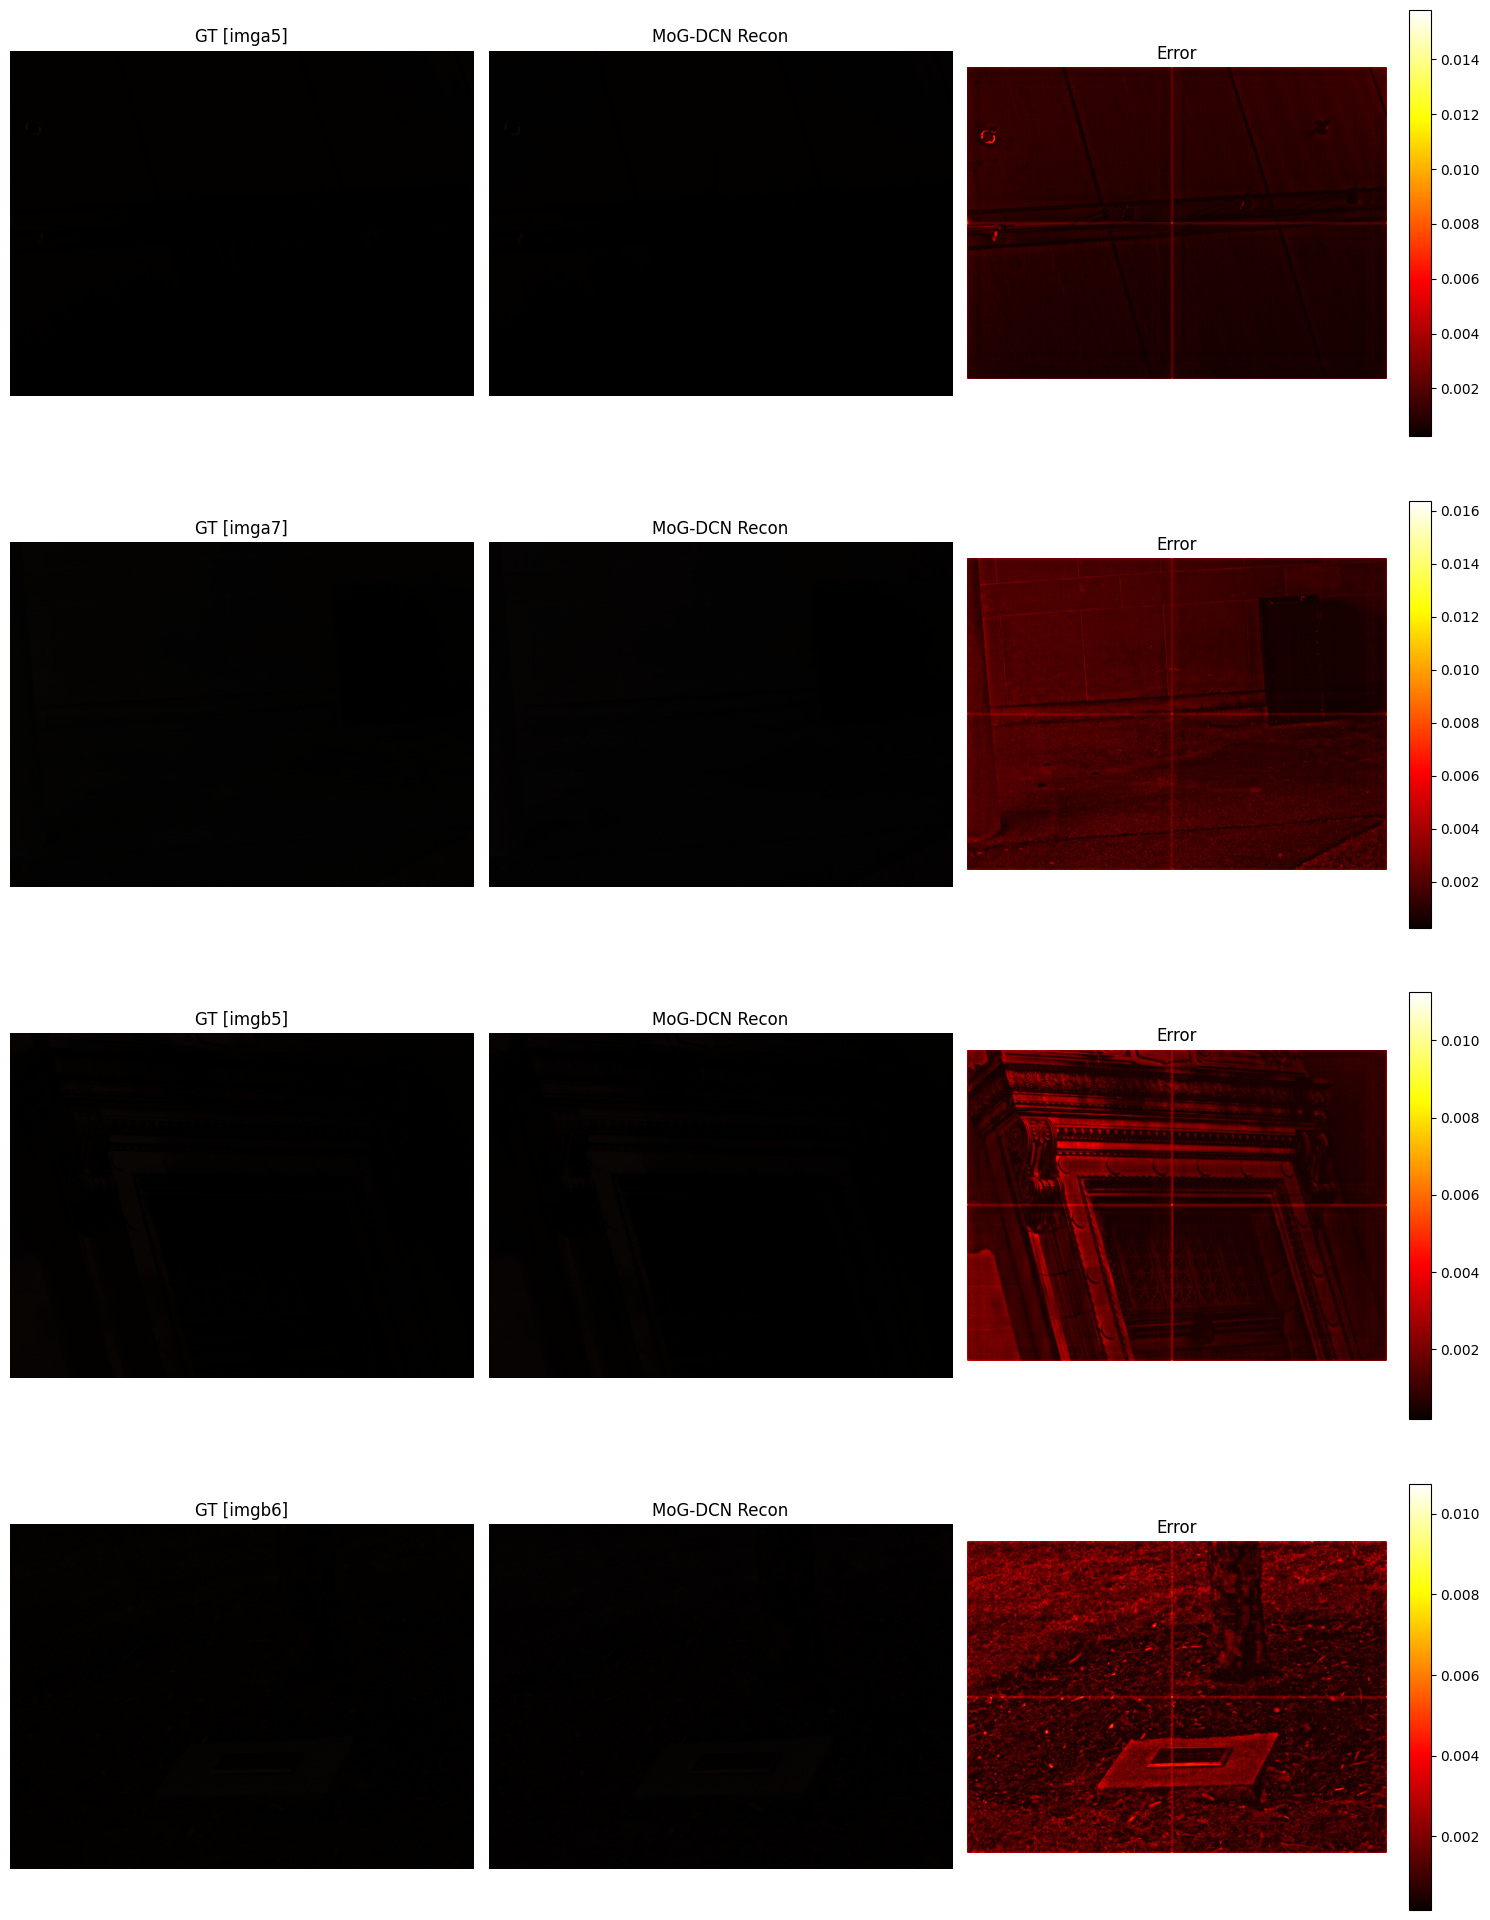

In [11]:
def to_rgb(h): return np.clip(h @ SRF, 0, 1)
n = min(4, len(results))
fig, ax = plt.subplots(n, 3, figsize=(15, 5*n))
if n == 1: ax = ax[np.newaxis, :]
for i in range(n):
    r = results[i]
    ax[i,0].imshow(to_rgb(r['gt']));   ax[i,0].set_title(f'GT [{r["name"]}]'); ax[i,0].axis('off')
    ax[i,1].imshow(to_rgb(r['pred'])); ax[i,1].set_title('MoG-DCN Recon');     ax[i,1].axis('off')
    im = ax[i,2].imshow(np.abs(r['gt']-r['pred']).mean(-1), cmap='hot')
    ax[i,2].set_title('Error'); ax[i,2].axis('off')
    plt.colorbar(im, ax=ax[i,2], fraction=0.046)
plt.tight_layout(); plt.savefig('/kaggle/working/mogdcn_vis.png', dpi=150); plt.show()

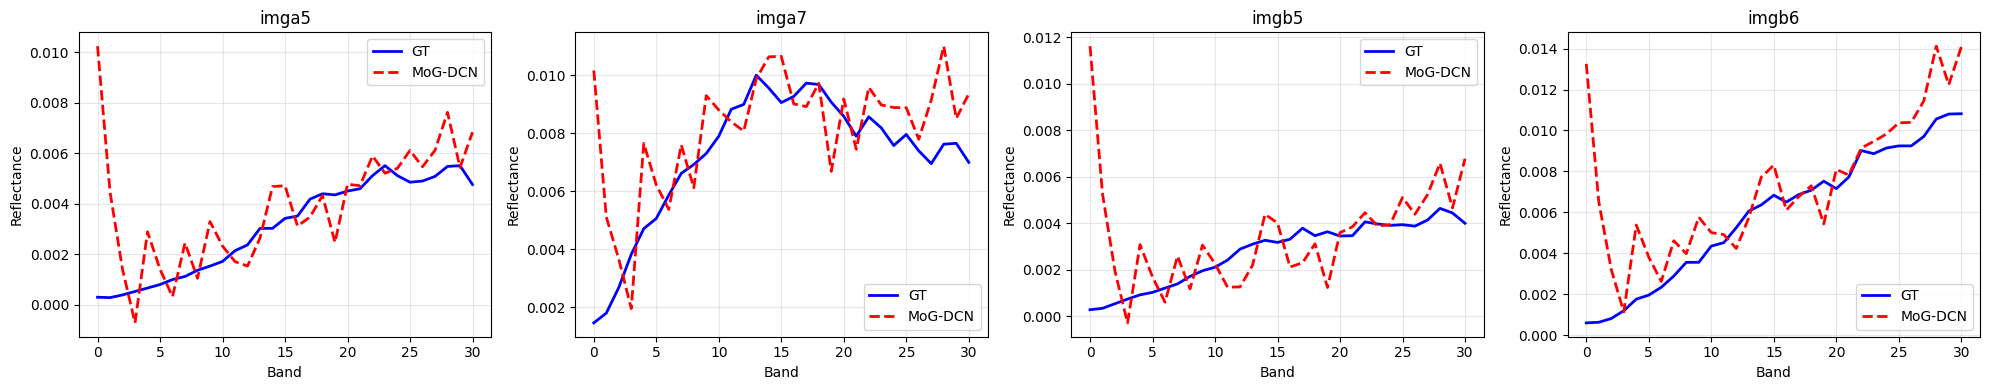

In [9]:
n = min(4, len(results))
fig, ax = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: ax = [ax]
for i in range(n):
    r = results[i]; H,W = r['gt'].shape[:2]; cy,cx = H//2, W//2
    ax[i].plot(r['gt'][cy,cx,:], 'b-', label='GT', lw=2)
    ax[i].plot(r['pred'][cy,cx,:], 'r--', label='MoG-DCN', lw=2)
    ax[i].set_title(r['name']); ax[i].legend(); ax[i].grid(alpha=0.3)
    ax[i].set_xlabel('Band'); ax[i].set_ylabel('Reflectance')
plt.tight_layout(); plt.show()